### Price elasticity of demand and of cancellation
* demand response along the booking curve: daily pickup for an arrival week against the rate offered that day, within hotel, arrival week and segment cells absorbed by demeaning, controlling for what the pricer sees
* elasticity per segment and hotel, placebo with a future rate, cluster bootstrap interval, regressor importance as absolute t statistics
* cancellation elasticity: probability of cancellation against the rate relative to the segment and month median
* market context: hedonic price model for Lisbon Airbnb listings with learning curves and feature importance, and the occupancy response to price
* exports the estimates used by the rate rules

In [1]:
import os
import json
import datetime
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
warnings.filterwarnings("ignore")

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
PARQUET_PATH = os.path.join(ROOT_DIR, "data", "parquet", "bookings.parquet")
LISTINGS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "airbnb_listings.parquet")
AVAILABILITY_PATH = os.path.join(ROOT_DIR, "data", "parquet", "airbnb_availability.parquet")
HOLIDAYS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "holidays.parquet")
PAGEVIEWS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "pageviews.parquet")
MODELS_DIR = os.path.join(ROOT_DIR, "data", "models")
pickup_segments = ["Online TA", "Offline TA/TO", "Direct"]
min_cell_days = 20
bootstrap_rounds = 60
rng = np.random.default_rng(7)
segments = ["Online TA", "Offline TA/TO", "Direct", "Groups", "Corporate"]

In [2]:
# load bookings with typed dates and a season label
def load_bookings(path):
    frame = pd.read_parquet(path)
    frame["arrival_date"] = pd.to_datetime(frame["arrival_date"])
    frame["booking_date"] = pd.to_datetime(frame["booking_date"])
    frame["month"] = frame["arrival_date"].dt.month
    frame["season"] = np.where(frame["month"].isin([6, 7, 8, 9]), "high", np.where(frame["month"].isin([4, 5, 10]), "shoulder", "low"))
    frame = frame[(frame["adr"] > 10) & (frame["adr"] < 1000) & (frame["nights"] > 0) & (frame["lead_time"] <= 365)]
    frame["arrival_week"] = frame["arrival_date"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
    return frame

In [3]:
# daily pickup panel: bookings made per day for each hotel, segment and arrival week, with the mean rate of those bookings
def pickup_panel(frame):
    grp = frame.groupby(["hotel", "market_segment", "arrival_week", "booking_date"])
    panel = grp.agg(pickup=("booking_id", "size"), room_nights=("nights", "sum"), rate=("adr", "mean"), lead=("lead_time", "mean")).reset_index()
    panel["days_to_arrival"] = (panel["arrival_week"] - panel["booking_date"]).dt.days
    panel["booking_dow"] = panel["booking_date"].dt.dayofweek
    panel["log_pickup"] = np.log(panel["pickup"])
    panel["log_rate"] = np.log(panel["rate"])
    return panel

In [4]:
# rooms already on the books for the arrival week at the start of each booking day, the pressure the pricer sees
def add_on_books(panel, frame):
    frame = frame.sort_values("booking_date")
    out = []
    for (hotel, week), part in panel.groupby(["hotel", "arrival_week"]):
        rows = frame[(frame["hotel"] == hotel) & (frame["arrival_week"] == week)]
        booked = rows["booking_date"].values
        leaves = rows["leave_books_date"].values
        days = part["booking_date"].values
        otb = np.array([int(((booked < d) & (leaves > d)).sum()) for d in days])
        pace = np.array([int(((booked >= d - np.timedelta64(7, "D")) & (booked < d)).sum()) for d in days])
        out.append(part.assign(on_books=otb, pace_7d=pace))
    return pd.concat(out, ignore_index=True)

In [5]:
# holiday counts in the booker markets and attention index per arrival week and per booking week
def add_demand_shifters(panel, holidays_path, pageviews_path):
    hol = pd.read_parquet(holidays_path)
    hol["date"] = pd.to_datetime(hol["date"])
    hol = hol[hol["kind"] == "public"]
    hol["week"] = hol["date"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
    counts = hol.groupby("week").size()
    panel["holidays_arrival_week"] = panel["arrival_week"].map(counts).fillna(0)
    pv = pd.read_parquet(pageviews_path)
    pv["date"] = pd.to_datetime(pv["date"])
    pv = pv[pv["project"].isin(["en.wikipedia", "de.wikipedia", "fr.wikipedia", "es.wikipedia", "pt.wikipedia"])]
    weekly = np.log(pv.groupby(pv["date"].dt.to_period("W-SUN").dt.end_time.dt.normalize())["views"].sum())
    panel["attention_booking_week"] = panel["booking_date"].dt.to_period("W-SUN").dt.end_time.dt.normalize().map(weekly)
    panel["attention_booking_week"] = panel["attention_booking_week"].fillna(weekly.mean())
    return panel

In [6]:
# fit the pickup specification on the within transformed panel with cluster robust standard errors, the cell fixed effects are absorbed by the demeaning
def fit_model(panel, cluster, extra=None):
    cols = regressor_columns() + ([] if extra is None else [extra])
    keys = ["hotel", "market_segment", "arrival_week"]
    demeaned = panel[cols + ["log_pickup"]] - panel.groupby(keys)[cols + ["log_pickup"]].transform("mean")
    return sm.OLS(demeaned["log_pickup"], demeaned[cols]).fit(cov_type="cluster", cov_kwds={"groups": panel[cluster]})

In [7]:
# rate coefficient of a fitted specification with its standard error, r2 is the within r2 of the demeaned panel
def summarize(model):
    return {"elasticity": round(float(model.params["log_rate"]), 3), "se": round(float(model.bse["log_rate"]), 3), "p": round(float(model.pvalues["log_rate"]), 4), "n": int(model.nobs), "r2": round(float(model.rsquared), 3)}

In [8]:
# fit one panel and return the rate coefficient with a cluster robust standard error
def fit(panel, cluster):
    return summarize(fit_model(panel, cluster))

In [9]:
# importance of the regressors as absolute t statistics
def regressor_importance(model):
    t = (model.params / model.bse).abs().dropna().sort_values(ascending=False)
    return [{"feature": k, "abs_t": round(float(v), 2), "coef": round(float(model.params[k]), 4)} for k, v in t.items()]

In [10]:
# regressors of the pickup specification: log rate, booking timing, pressure on the books and demand shifters, with weekday dummies
def regressor_columns():
    return ["log_rate", "log1p_days_to_arrival", "log1p_on_books", "log1p_pace_7d", "attention_booking_week"] + ["dow_" + str(d) for d in range(1, 7)]

In [11]:
# add the transformed regressors and the weekday dummies to the panel
def add_regressors(panel):
    out = panel.copy()
    out["log1p_days_to_arrival"] = np.log1p(out["days_to_arrival"])
    out["log1p_on_books"] = np.log1p(out["on_books"])
    out["log1p_pace_7d"] = np.log1p(out["pace_7d"])
    for d in range(1, 7):
        out["dow_" + str(d)] = (out["booking_dow"] == d).astype(float)
    return out

In [12]:
# placebo: the rate offered seven days later should not move today's pickup once the cell is fixed
def placebo(panel):
    shifted = panel.sort_values(["hotel", "market_segment", "arrival_week", "booking_date"]).copy()
    shifted["future_rate"] = shifted.groupby(["hotel", "market_segment", "arrival_week"])["log_rate"].shift(-7)
    part = shifted.dropna(subset=["future_rate"])
    model = fit_model(part, "arrival_week", extra="future_rate")
    return {"future_rate_coef": round(float(model.params["future_rate"]), 3), "future_rate_p": round(float(model.pvalues["future_rate"]), 4), "current_rate_coef": round(float(model.params["log_rate"]), 3), "n": int(model.nobs)}

In [13]:
# cluster bootstrap of the pickup specification over arrival weeks
def bootstrap(panel, rounds):
    weeks = panel["arrival_week"].unique()
    groups = {w: part for w, part in panel.groupby("arrival_week")}
    values = []
    for i in range(rounds):
        pick = rng.choice(weeks, size=len(weeks), replace=True)
        sample = pd.concat([groups[w] for w in pick], ignore_index=True)
        model = fit_model(sample, "arrival_week")
        values.append(float(model.params["log_rate"]))
    return float(np.percentile(values, 2.5)), float(np.percentile(values, 97.5))

In [14]:
# elasticity per segment and per hotel from the pickup specification
def by_group(panel):
    rows = []
    for key, part in list(panel.groupby("market_segment")) + list(panel.groupby("hotel")):
        if part["arrival_week"].nunique() < 20:
            continue
        r = fit(part, "arrival_week")
        r["group"] = key
        rows.append(r)
    return pd.DataFrame(rows)

In [15]:
# cancellation elasticity, logit of cancellation on the log rate relative to the hotel, segment and month median
def cancellation_elasticity(frame):
    part = frame[frame["market_segment"].isin(segments) & (frame["deposit_type"] == "No Deposit") & (frame["outcome_known"] == True)].copy()
    part["is_canceled"] = part["is_canceled"].astype(int)
    med = part.groupby(["hotel", "market_segment", "month"])["adr"].transform("median")
    part["rel_price"] = np.log(part["adr"] / med)
    part["lead_bucket"] = pd.cut(part["lead_time"], [-1, 7, 30, 90, 1000], labels=["0-7", "8-30", "31-90", "90+"])
    model = smf.logit("is_canceled ~ rel_price + C(hotel):C(market_segment) + C(month) + C(lead_bucket) + total_of_special_requests + previous_cancellations", data=part).fit(disp=0)
    base = part["is_canceled"].mean()
    marginal = float(model.params["rel_price"]) * base * (1 - base)
    out = {"logit_coef": round(float(model.params["rel_price"]), 3), "se": round(float(model.bse["rel_price"]), 3), "p": round(float(model.pvalues["rel_price"]), 4), "points_per_10pct_price": round(marginal * np.log(1.1) * 100, 2), "n": int(model.nobs)}
    return model, out, part

In [16]:
# cancellation rate by relative price decile
def plot_cancel_by_price(part):
    part = part.copy()
    part["decile"] = pd.qcut(part["rel_price"], 10, labels=False, duplicates="drop")
    curve = part.groupby("decile").agg(rel_price=("rel_price", "mean"), cancel_rate=("is_canceled", "mean"), n=("is_canceled", "size"))
    plt.figure(figsize=(7, 4))
    plt.plot(np.exp(curve["rel_price"]), curve["cancel_rate"], marker="o", color="red")
    plt.xlabel("rate relative to segment and month median")
    plt.ylabel("cancel rate")
    plt.title("Cancellation by relative rate")
    plt.show()
    return curve.round(3)

In [17]:
# airbnb listings with price, occupancy proxy and cleaned features
def load_listings(listings_path, availability_path):
    frame = pd.read_parquet(listings_path)
    avail = pd.read_parquet(availability_path)
    frame["id"] = pd.to_numeric(frame["id"], errors="coerce")
    frame = frame.merge(avail, left_on="id", right_on="listing_id", how="left")
    frame["price"] = pd.to_numeric(frame["price_num"], errors="coerce")
    frame = frame[(frame["price"] >= 20) & (frame["price"] <= 1500)].copy()
    for col in ["accommodates", "bedrooms", "beds", "bathrooms", "minimum_nights", "number_of_reviews", "review_scores_rating", "review_scores_location", "review_scores_value", "host_listings_count", "reviews_per_month", "latitude", "longitude", "availability_365"]:
        frame[col] = pd.to_numeric(frame[col], errors="coerce")
    frame["superhost"] = (frame["host_is_superhost"] == "t").astype(int)
    frame["instant"] = (frame["instant_bookable"] == "t").astype(int)
    frame["booked_share"] = frame["booked_days"] / frame["days"]
    frame["log_price"] = np.log(frame["price"])
    frame["amenity_count"] = frame["amenities"].fillna("").str.count(",") + 1
    frame["dist_center_km"] = np.sqrt(((frame["latitude"] - 38.7139) * 111) ** 2 + ((frame["longitude"] + 9.1394) * 88) ** 2)
    return frame

In [18]:
# mean learning curve over the folds up to the shortest fold, rmse and r2 per iteration on the train and test sets, r2 as one minus mse over the variance of log price
def hedonic_curve(histories, y):
    var = float(np.var(y))
    length = min(len(h["train"]["l2"]) for h in histories)
    train_l2 = np.mean([h["train"]["l2"][:length] for h in histories], axis=0)
    test_l2 = np.mean([h["test"]["l2"][:length] for h in histories], axis=0)
    out = {}
    out["iteration"] = list(range(1, len(train_l2) + 1))
    out["train_rmse"] = np.sqrt(train_l2).round(5).tolist()
    out["test_rmse"] = np.sqrt(test_l2).round(5).tolist()
    out["train_r2"] = (1 - train_l2 / var).round(5).tolist()
    out["test_r2"] = (1 - test_l2 / var).round(5).tolist()
    return out

In [19]:
# hedonic price model for listings, strongly regularised gradient boosting (seven leaves, 150 listings per leaf, half the features per tree) with early stopping on every fold, cross validated r2 and the loss per iteration; the final model takes the median best iteration of the folds
def hedonic_model(frame):
    features = ["accommodates", "bedrooms", "beds", "bathrooms", "minimum_nights", "number_of_reviews", "review_scores_rating", "review_scores_location", "review_scores_value", "host_listings_count", "reviews_per_month", "superhost", "instant", "amenity_count", "dist_center_km", "latitude", "longitude", "neighbourhood_cleansed", "room_type", "property_type"]
    x = frame[features].copy()
    for col in ["neighbourhood_cleansed", "room_type", "property_type"]:
        x[col] = x[col].astype("category")
    y = frame["log_price"].values
    params = {"objective": "regression", "metric": "l2", "learning_rate": 0.03, "num_leaves": 7, "min_data_in_leaf": 150, "feature_fraction": 0.5, "bagging_fraction": 0.8, "bagging_freq": 1, "lambda_l2": 30.0, "cat_smooth": 50.0, "min_gain_to_split": 0.01, "verbose": -1, "num_threads": 3, "seed": 7}
    preds = np.zeros(len(y))
    histories = []
    best = []
    for train_idx, test_idx in KFold(5, shuffle=True, random_state=7).split(x):
        d_train = lgb.Dataset(x.iloc[train_idx], label=y[train_idx])
        d_test = lgb.Dataset(x.iloc[test_idx], label=y[test_idx], reference=d_train)
        history = {}
        model = lgb.train(params, d_train, num_boost_round=5000, valid_sets=[d_train, d_test], valid_names=["train", "test"], callbacks=[lgb.early_stopping(50, verbose=False), lgb.record_evaluation(history)])
        preds[test_idx] = model.predict(x.iloc[test_idx], num_iteration=model.best_iteration)
        histories.append(history)
        best.append(int(model.best_iteration))
    rounds = int(np.median(best))
    final = lgb.train(params, lgb.Dataset(x, label=y), num_boost_round=rounds)
    r2 = r2_score(y, preds)
    frame = frame.assign(pred_log_price=preds, price_gap=np.exp(frame["log_price"] - preds) - 1)
    curve = hedonic_curve(histories, y)
    curve["best_iteration"] = rounds
    return final, r2, frame, curve

In [20]:
# learning curves of the hedonic model, train against test per boosting iteration for rmse and r2
def plot_hedonic_curves(curve):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(curve["iteration"], curve["train_rmse"], color="blue", label="train")
    axes[0].plot(curve["iteration"], curve["test_rmse"], color="red", label="test")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("rmse of log price")
    axes[0].legend()
    axes[1].plot(curve["iteration"], curve["train_r2"], color="blue", label="train")
    axes[1].plot(curve["iteration"], curve["test_r2"], color="red", label="test")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("r2")
    axes[1].legend()
    fig.suptitle("Learning curves")
    plt.tight_layout()
    plt.show()

In [21]:
# gain share per feature of the final hedonic model, sorted by importance
def hedonic_importance(model):
    imp = pd.Series(model.feature_importance("gain"), index=model.feature_name())
    share = (imp / imp.sum()).sort_values(ascending=False)
    return [{"feature": k, "gain": round(float(imp[k]), 1), "share": round(float(v), 4)} for k, v in share.items()]

In [22]:
# neighbourhood premiums, median price and occupancy proxy per neighbourhood
def neighbourhood_table(frame):
    grp = frame.groupby("neighbourhood_cleansed").agg(listings=("id", "size"), median_price=("price", "median"), booked_share=("booked_share", "mean"), rating=("review_scores_rating", "mean"), entire_home_share=("room_type", lambda s: float((s == "Entire home/apt").mean())))
    grp = grp[grp["listings"] >= 100].sort_values("median_price", ascending=False)
    return grp.round(3)

In [23]:
# occupancy proxy against relative price, cross sectional demand response
def airbnb_price_response(frame):
    part = frame[(frame["number_of_reviews"] >= 3) & frame["booked_share"].notna()].copy()
    part["decile"] = pd.qcut(part["price_gap"], 10, labels=False, duplicates="drop")
    curve = part.groupby("decile").agg(price_gap=("price_gap", "mean"), booked_share=("booked_share", "mean"), n=("id", "size"))
    model = smf.ols("booked_share ~ price_gap + C(neighbourhood_cleansed) + C(room_type)", data=part).fit(cov_type="HC1")
    return curve.round(3), round(float(model.params["price_gap"]), 4), round(float(model.bse["price_gap"]), 4)

In [24]:
# save all estimates with the learning curve and importance of the hedonic model and the regressor importance of the pickup model
def export(pickup, pickup_importance, groups, plac, ci, cancel, hedonic_r2, hedonic_curve_out, hedonic_imp, neighbourhoods, airbnb_slope, airbnb_se, curve):
    os.makedirs(MODELS_DIR, exist_ok=True)
    ota = groups[groups["group"] == "Online TA"].iloc[0].to_dict() if (groups["group"] == "Online TA").any() else {}
    out = {"pickup": {"overall": pickup, "by_group": groups.to_dict("records"), "placebo": plac, "bootstrap_ci": {"low": round(ci[0], 3), "high": round(ci[1], 3)}, "online_ta": {k: ota.get(k) for k in ["elasticity", "se", "p", "n"]}, "importance": pickup_importance, "method": "daily pickup for an arrival week against the rate offered that day, within hotel, arrival week and segment cells absorbed by demeaning, controlling for days to arrival, booking weekday, rooms on the books, recent pace and source market attention"},
           "cancellation": cancel, "airbnb": {"hedonic_r2": round(hedonic_r2, 3), "booked_share_per_unit_price_gap": airbnb_slope, "se": airbnb_se, "neighbourhoods": neighbourhoods.reset_index().to_dict("records"), "price_curve": curve.reset_index().to_dict("records"), "learning_curve": hedonic_curve_out, "importance": hedonic_imp}, "generated_at": datetime.datetime.now(datetime.timezone.utc).isoformat()}
    with open(os.path.join(MODELS_DIR, "elasticity.json"), "w") as f:
        json.dump(out, f, indent=2)
    print("saved " + os.path.join(MODELS_DIR, "elasticity.json"))

In [25]:
bookings = load_bookings(PARQUET_PATH)
panel = pickup_panel(bookings)
panel = add_on_books(panel, bookings)
panel = add_demand_shifters(panel, HOLIDAYS_PATH, PAGEVIEWS_PATH)
cells_ok = panel.groupby(["hotel", "market_segment", "arrival_week"])["booking_date"].transform("size") >= min_cell_days
panel = add_regressors(panel[cells_ok].reset_index(drop=True))
print("panel rows " + str(len(panel)) + ", arrival weeks " + str(panel["arrival_week"].nunique()) + ", cells " + str(panel.groupby(["hotel", "market_segment", "arrival_week"]).ngroups))
pickup_model = fit_model(panel, "arrival_week")
pickup = summarize(pickup_model)
print("pickup elasticity, full specification " + json.dumps(pickup))
pickup_importance = regressor_importance(pickup_model)
print("regressor importance, absolute t statistics")
print(pd.DataFrame(pickup_importance).to_string(index=False))
groups = by_group(panel)
print(groups.to_string(index=False))
plac = placebo(panel)
print("placebo " + json.dumps(plac))
ci = bootstrap(panel, bootstrap_rounds)
print("bootstrap interval " + str(round(ci[0], 3)) + " to " + str(round(ci[1], 3)))

panel rows 403845, arrival weeks 701, cells 5431


pickup elasticity, full specification {"elasticity": 0.048, "se": 0.002, "p": 0.0, "n": 403845, "r2": 0.157}
regressor importance, absolute t statistics
               feature  abs_t    coef
         log1p_pace_7d  60.28  0.1586
 log1p_days_to_arrival  48.97 -0.0897
        log1p_on_books  28.72 -0.0404
              log_rate  19.90  0.0477
                 dow_6  11.01 -0.0271
                 dow_5   8.76 -0.0208
                 dow_4   7.18 -0.0176
                 dow_3   5.12 -0.0124
                 dow_2   4.55 -0.0109
attention_booking_week   2.46  0.0238
                 dow_1   2.35 -0.0056


 elasticity    se      p      n    r2         group
      0.004 0.023 0.8567   9498 0.143     Corporate
      0.020 0.005 0.0000  79736 0.271        Direct
      0.026 0.004 0.0000  81410 0.029        Groups
      0.029 0.004 0.0000  87285 0.060 Offline TA/TO
      0.036 0.004 0.0000 145916 0.246     Online TA
      0.060 0.004 0.0000 255556 0.147    City Hotel
      0.033 0.003 0.0000 148289 0.188  Resort Hotel


placebo {"future_rate_coef": -0.001, "future_rate_p": 0.6151, "current_rate_coef": 0.036, "n": 365828}


bootstrap interval 0.043 to 0.052


cancellation elasticity {"logit_coef": 0.218, "se": 0.009, "p": 0.0, "points_per_10pct_price": 0.42, "n": 556255}


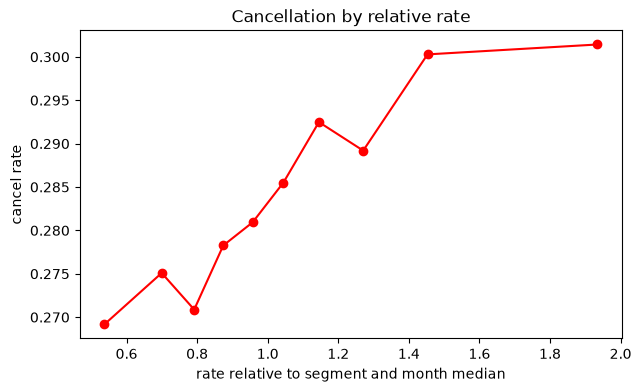

        rel_price  cancel_rate      n
decile                               
0          -0.622        0.269  55626
1          -0.357        0.275  55625
2          -0.234        0.271  55627
3          -0.135        0.278  55624
4          -0.044        0.281  55696
5           0.044        0.286  55556
6           0.136        0.292  55624
7           0.240        0.289  55627
8           0.374        0.300  55624
9           0.660        0.301  55626


In [26]:
model_c, cancel, part = cancellation_elasticity(bookings)
print("cancellation elasticity " + json.dumps(cancel))
print(plot_cancel_by_price(part).to_string())

listings 22478, hedonic cross validated r2 on log price 0.756
best iteration 3724, mean over 5 folds at the shortest fold, rmse train 0.29103, test 0.32412, r2 train 0.80092, test 0.75308


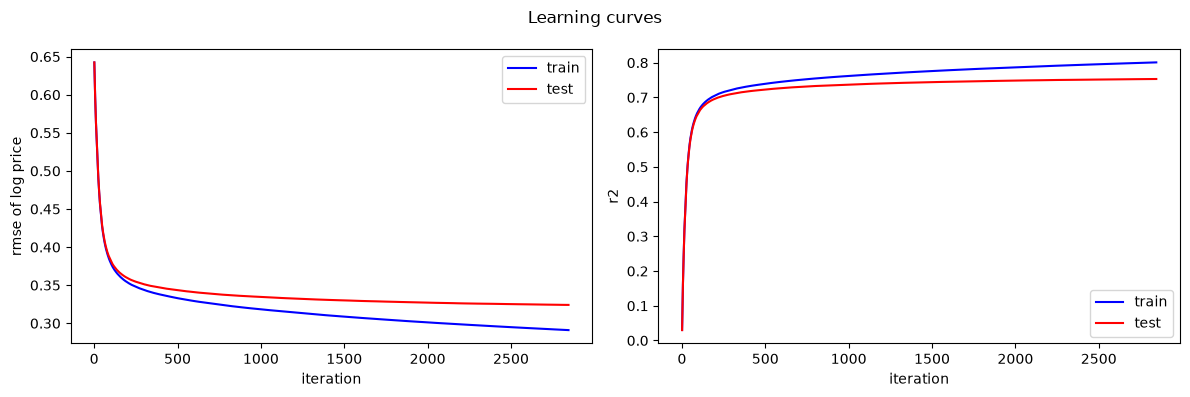

               feature    gain  share
          accommodates 28226.3 0.2585
              bedrooms 15803.2 0.1447
         property_type 15242.4 0.1396
             bathrooms 10067.2 0.0922
             room_type  8380.2 0.0768
neighbourhood_cleansed  5685.3 0.0521
                  beds  3762.1 0.0345
        minimum_nights  3729.1 0.0342
     reviews_per_month  2883.8 0.0264
review_scores_location  2801.7 0.0257
                                                  listings  median_price  booked_share  rating  entire_home_share
neighbourhood_cleansed                                                                                           
Colares                                                438       200.000         0.340   4.769              0.779
Cascais e Estoril                                     1452       185.500         0.392   4.734              0.791
Ericeira                                               659       162.000         0.398   4.802              0.789
Parque das N

booked share change per unit of price gap -0.0393, se 0.0062
        price_gap  booked_share     n
decile                               
0          -0.382         0.390  1778
1          -0.234         0.356  1778
2          -0.158         0.360  1778
3          -0.096         0.352  1777
4          -0.037         0.354  1778
5           0.023         0.364  1778
6           0.091         0.352  1777
7           0.178         0.339  1778
8           0.310         0.332  1778
9           0.770         0.330  1778


In [27]:
listings = load_listings(LISTINGS_PATH, AVAILABILITY_PATH)
hedonic, hedonic_r2, listings, hedonic_curve_out = hedonic_model(listings)
print("listings " + str(len(listings)) + ", hedonic cross validated r2 on log price " + str(round(hedonic_r2, 3)))
print("best iteration " + str(hedonic_curve_out["best_iteration"]) + ", mean over 5 folds at the shortest fold, rmse train " + str(hedonic_curve_out["train_rmse"][-1]) + ", test " + str(hedonic_curve_out["test_rmse"][-1]) + ", r2 train " + str(hedonic_curve_out["train_r2"][-1]) + ", test " + str(hedonic_curve_out["test_r2"][-1]))
plot_hedonic_curves(hedonic_curve_out)
hedonic_imp = hedonic_importance(hedonic)
print(pd.DataFrame(hedonic_imp).head(10).to_string(index=False))
neighbourhoods = neighbourhood_table(listings)
print(neighbourhoods.head(12).to_string())
curve, slope, se = airbnb_price_response(listings)
print("booked share change per unit of price gap " + str(slope) + ", se " + str(se))
print(curve.to_string())

In [28]:
export(pickup, pickup_importance, groups, plac, ci, cancel, hedonic_r2, hedonic_curve_out, hedonic_imp, neighbourhoods, slope, se, curve)

saved /srv/data/models/elasticity.json
